In [7]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from astropy.io import fits
from astropy.wcs import WCS 
from astroscrappy import detect_cosmics
# from lacosmic import lacosmic

from mgefit.find_galaxy import find_galaxy


import sys
sys.path.append("./functions")

# Own function imports 
from plotting import imdisplay
from extractdata import extractData
from backgroundmodel import mainBackgroundEstimation
from ellipsemodels import MainFitEllipseModel, fitApertureModel
from sourcemasking import maskBackgroundSources, maskCircle, createRequiredVariables
from empiricalpsf import extractPsfSources
from fourierfunctions import calculateSBF, appSBFmagnitude
from librarypsfhubble import calculateLibrarySBF
from sbfuncertainties import sbfMagnitudeAnnuliSigmas

version = "2.1"

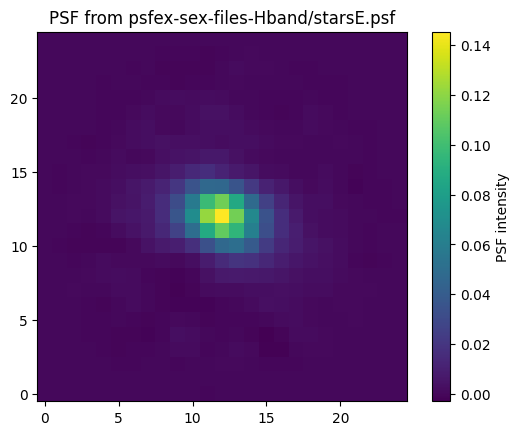

In [8]:
def getpsf(file_path):
    psf_data, psf_header = fits.getdata(file_path, ext=1, header=True) 

    plt.imshow(psf_data[0][0][0], origin="lower", cmap="viridis")
    plt.colorbar(label=f"PSF intensity")
    plt.title(f"PSF from {file_path}")
    plt.show()    
    psf = psf_data[0][0][0]
    psf = psf / np.sum(psf)  # Normalize the PSF
    return psf
psf_path = 'psfex-sex-files-Hband/starsE.psf'
psf = getpsf(psf_path)

version 2.1
computing galaxy from Euclid/data/dwarfsH/E/flt

1. Extracting the data ...


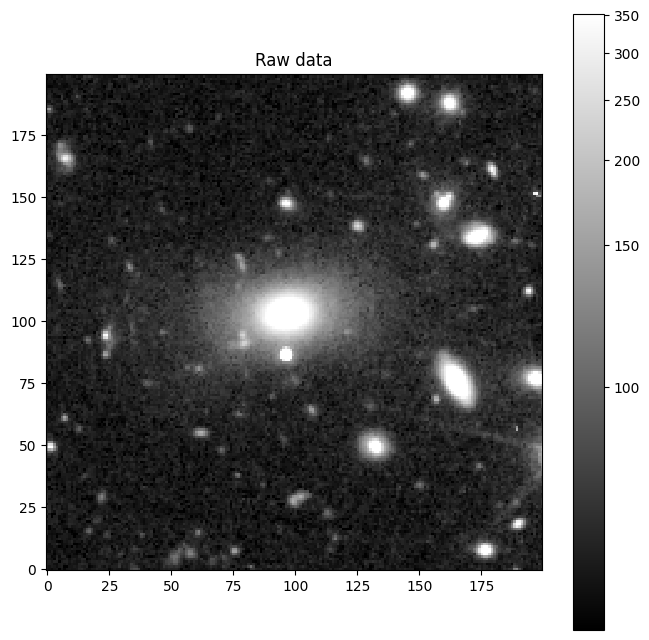


2. Performing background estimation ...


  0%|          | 0/20 [00:00<?, ?it/s]/root/MasterThesis/SBF_Pipeline/.venv/lib/python3.12/site-packages/astropy/modeling/functional_models.py:879: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
  5%|▌         | 1/20 [00:01<00:29,  1.55s/it]/root/MasterThesis/SBF_Pipeline/functions/backgroundmodel.py:44: RuntimeWarning: invalid value encountered in log10
  return np.log10(sersic_profile + noise)
100%|██████████| 20/20 [00:37<00:00,  1.86s/it]


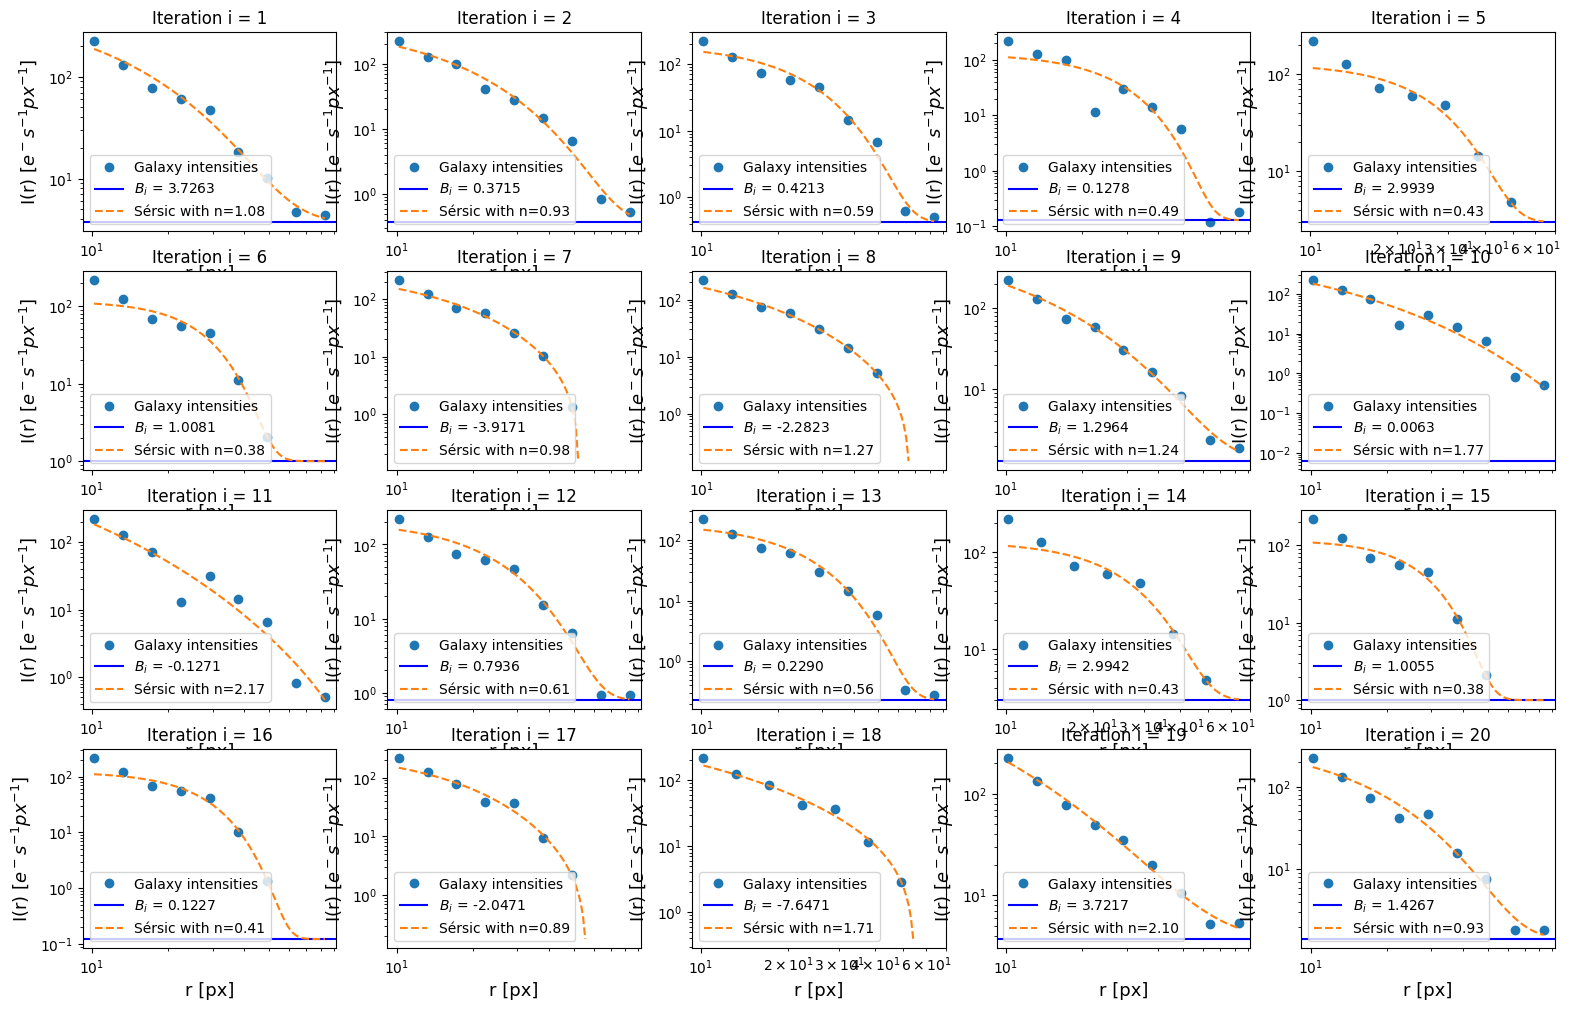

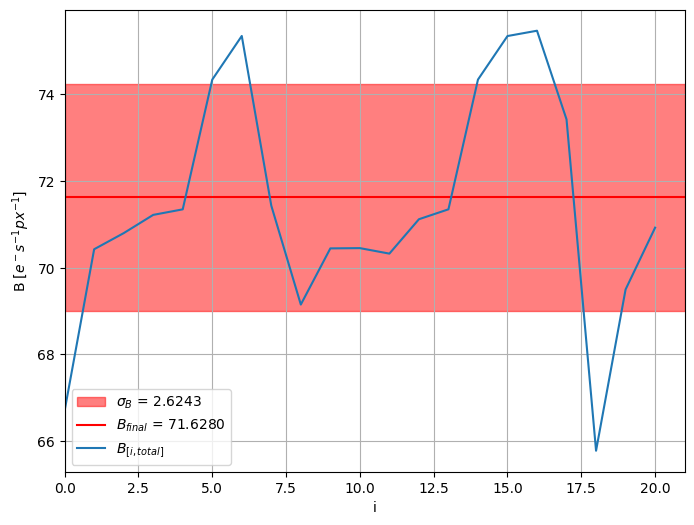

In [9]:
# core_path = 'Euclid/data/rand1/VIS/'
# data_path = core_path + 'gal/rand_VIS_band.fits'
# file_path= core_path + 'return_files'
# image_path= core_path + 'images'

core_path = 'Euclid/data/test/dwarfsH/E/'
data_path = 'Euclid/data/dwarfsH/E/flt'
file_path= core_path + 'return_files'
image_path= core_path + 'images'
make_plots=True
plot_plots=True
psf=psf
geometry=None
maxarea_sourcemask=None
filter="H"
background_estimation=True
background=None #8.6088
ellipsefitter='v1'
cosmic_ray_method='astroscrappy'

print(f"version {version}")
print(f'computing galaxy from {data_path}')
print("\n1. Extracting the data ...")

data, mask_cr, wcs, mzp = extractData(data_path, file_path=file_path, image_path=image_path, make_plots=make_plots, plot_plots=plot_plots, filter=filter, cosmic_ray_method=cosmic_ray_method)


if background_estimation:
    print("\n2. Performing background estimation ...")
    data, total_bckgr, sex_bckgr = mainBackgroundEstimation(data, mask_cr, image_path=image_path, make_plots=make_plots, plot_plots=plot_plots)

else:
    print("\n2. No background estimation performed ...")
    sex_bckgr = 0
    if background != None:
        total_bckgr = background
        data -= total_bckgr
    else:
        total_bckgr = 0

if file_path != None:
    np.savetxt(file_path + "/background", [total_bckgr, sex_bckgr])


5. Fitting aperture ellipse model ...


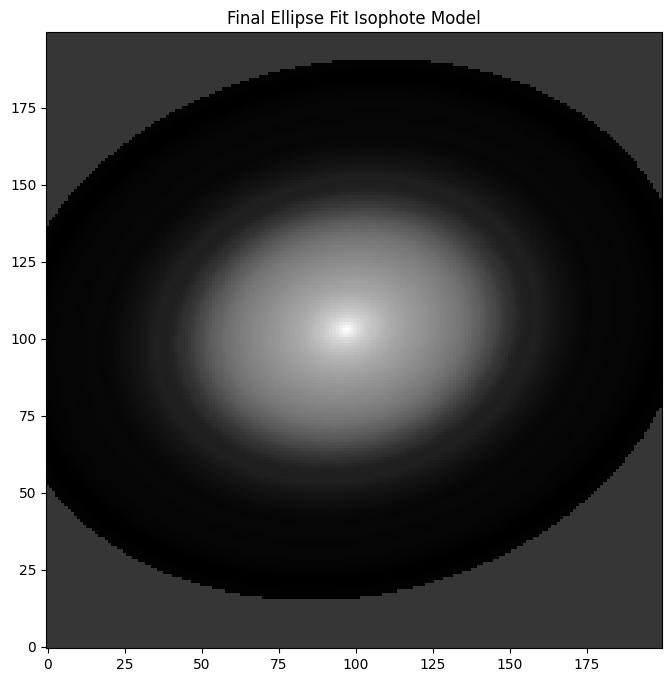

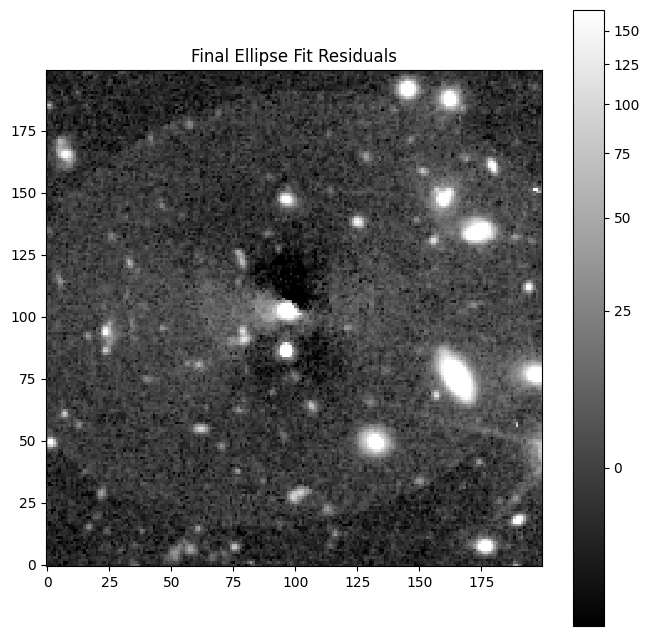

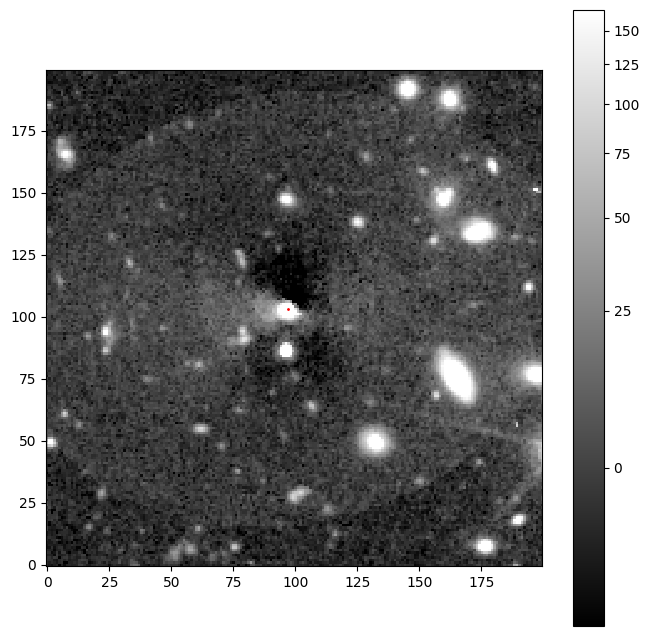

In [10]:
ellipsefitter = 'a1'
print("\n5. Fitting aperture ellipse model ...")
residual_final, model_final, geometry = fitApertureModel(data, mask_cr=mask_cr, geometry=None, make_plots=make_plots, plot_plots=plot_plots, final=True, image_path=image_path, sclipmaxiters=5)
print(geometry)

fig,ax = plt.subplots(figsize=(8,8))
imdisplay(residual_final, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.scatter(geometry.x0,geometry.y0, c='red', s=1)
plt.show()


3. Fitting initial ellipse model ...


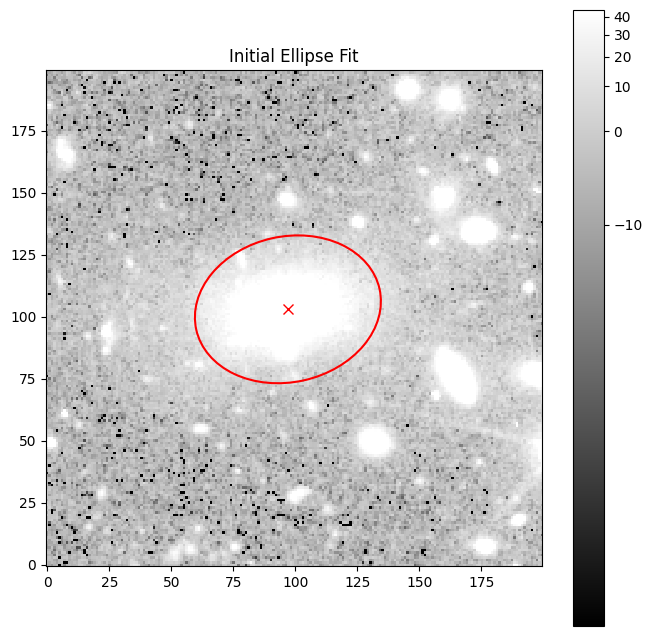

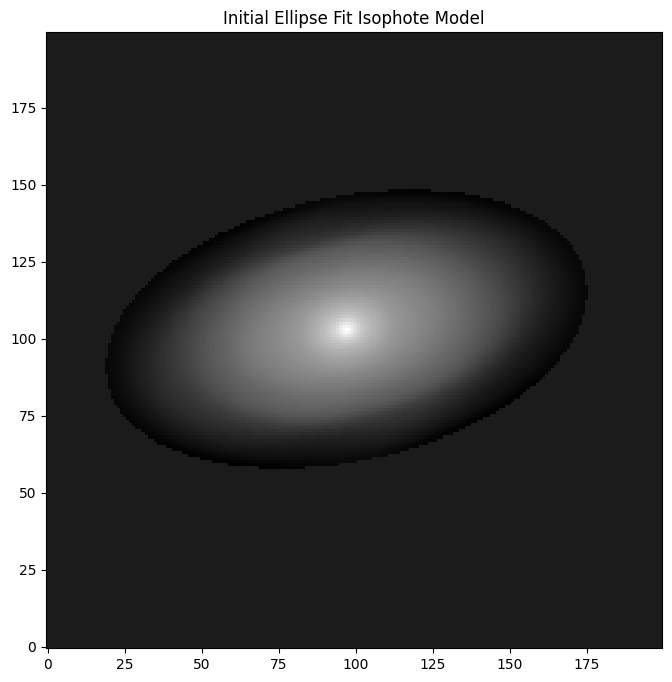

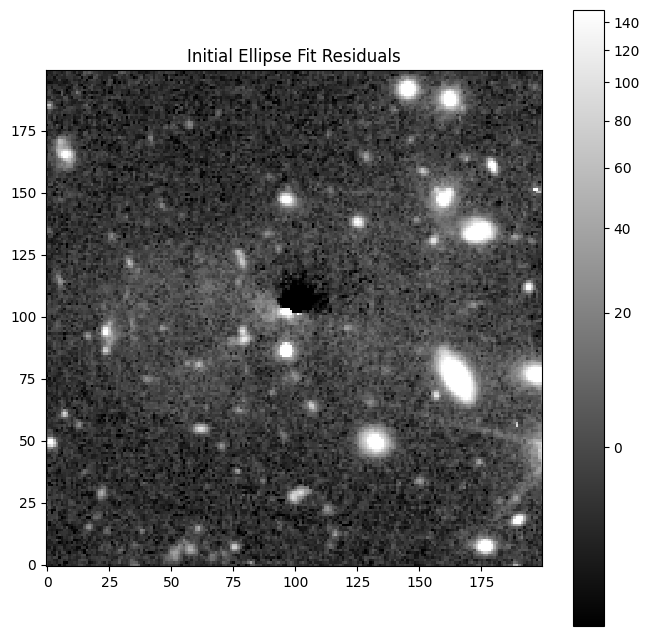


4. Finding initial source mask ...


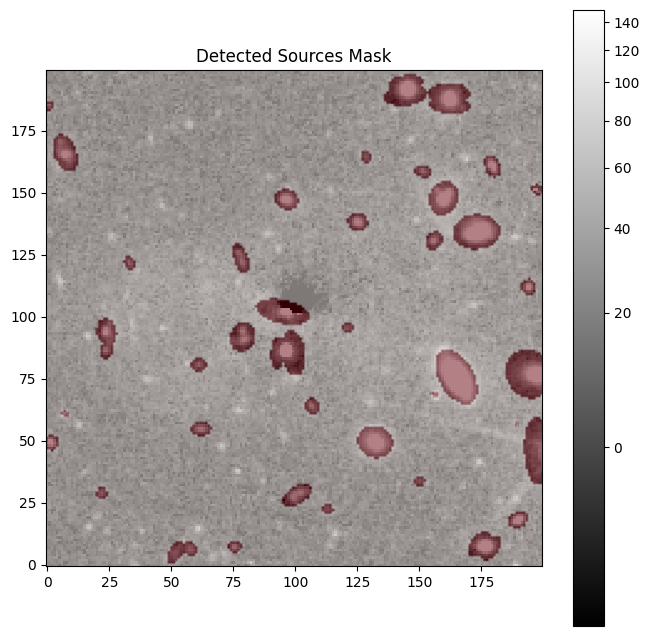


5. Fitting final ellipse model ...
Center pixel is masked - unmasking central area.


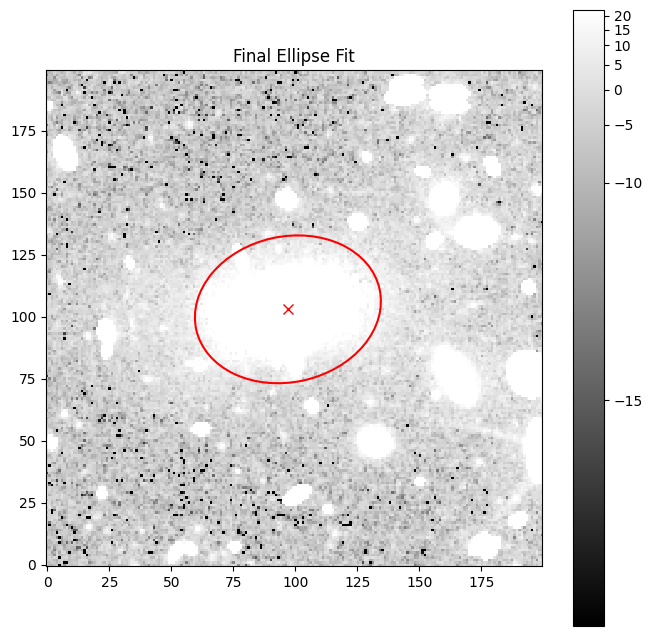

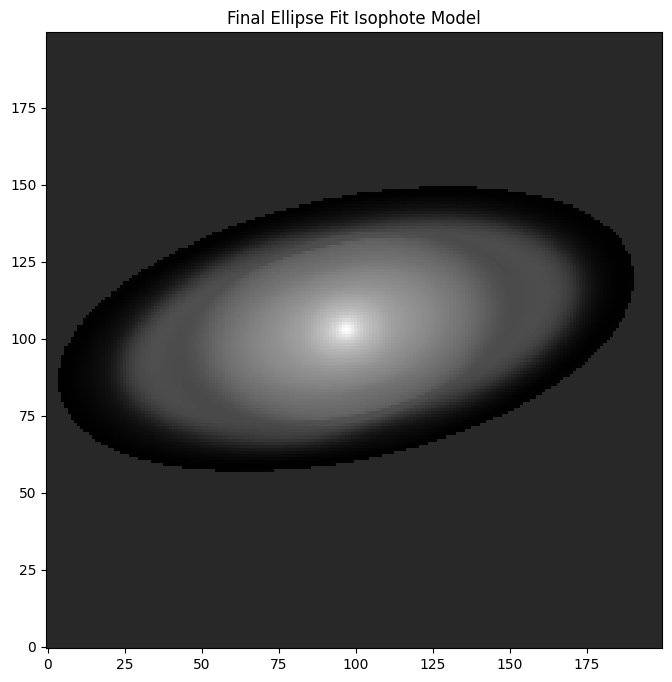

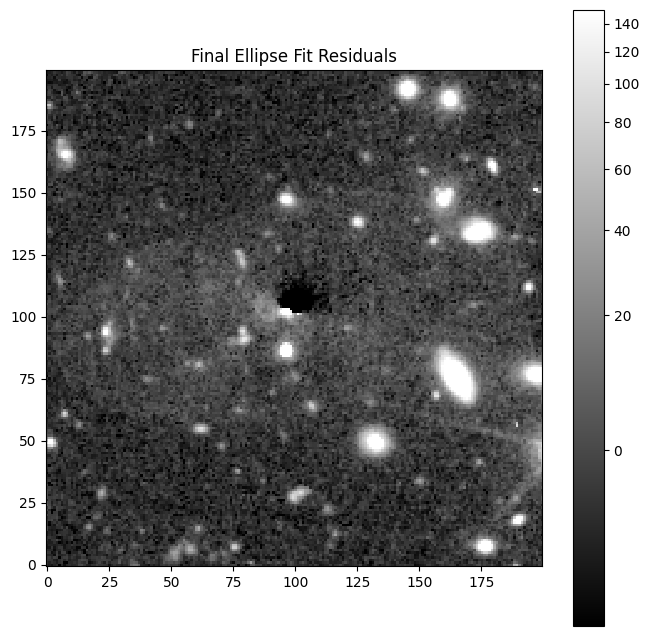

In [11]:
ellipsefitter = 'v3'
print("\n3. Fitting initial ellipse model ...")
residual_basic, model_basic, geometry = MainFitEllipseModel(data, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, final=False, method=ellipsefitter)

print("\n4. Finding initial source mask ...")
source_mask = maskBackgroundSources(residual_basic, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, r=3)

print("\n5. Fitting final ellipse model ...")
residual_final, model_final, geometry = MainFitEllipseModel(data, mask_cr=source_mask, geometry=geometry, make_plots=make_plots, plot_plots=plot_plots, final=True, image_path=image_path,method=ellipsefitter)
print(geometry)


3. Fitting initial ellipse model ...


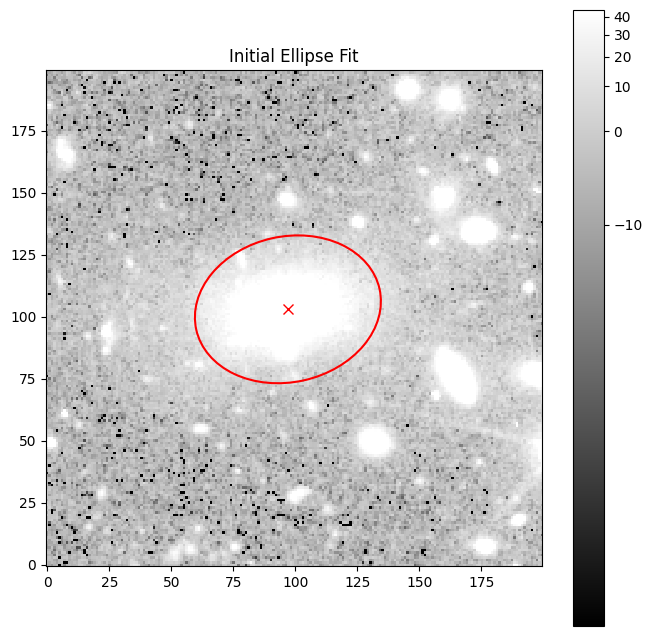

inside_non_fixed modification used
[ True  True  True False]
[False False  True False]


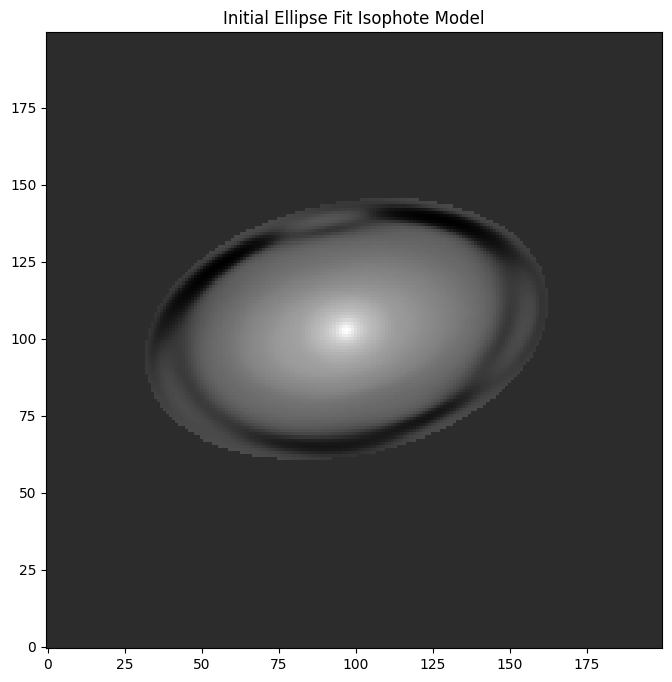

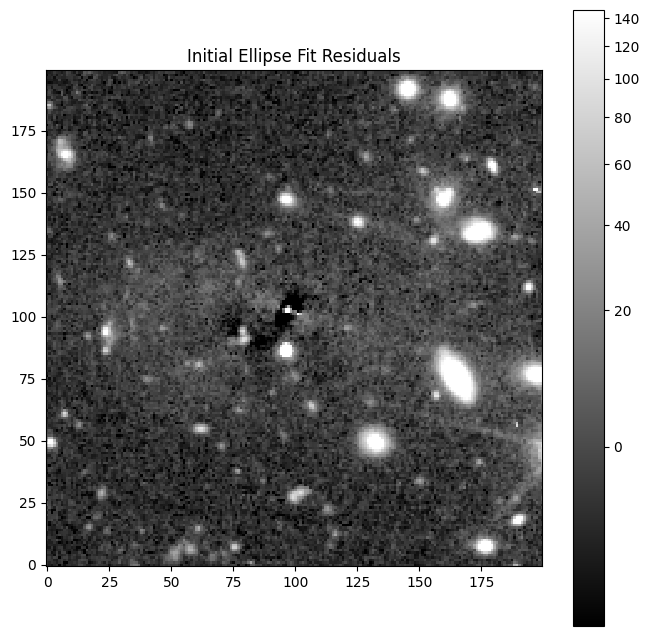


4. Finding initial source mask ...


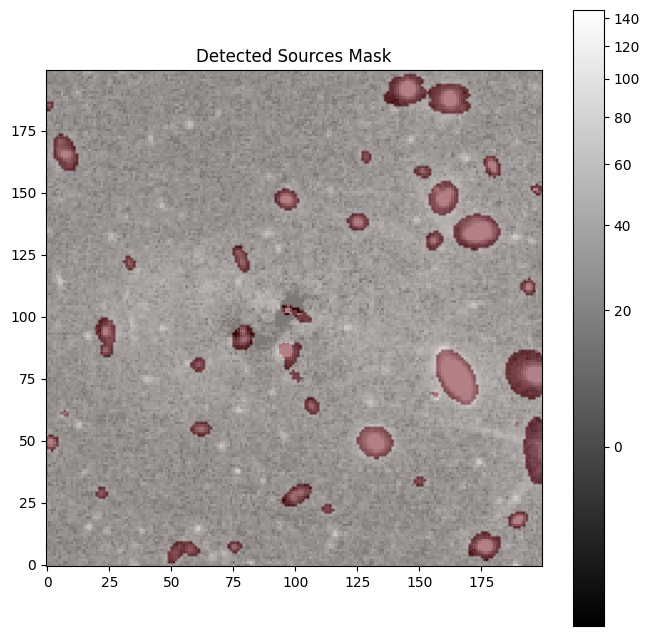


5. Fitting final ellipse model ...
Center pixel is masked - unmasking central area.


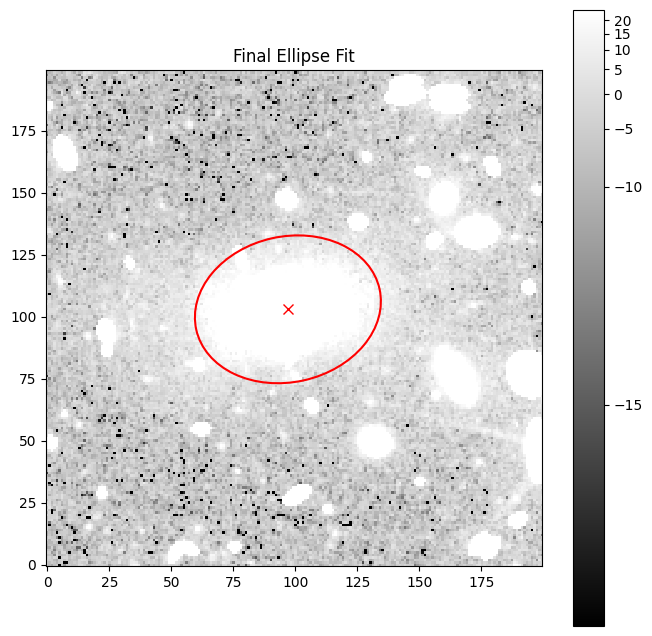

inside_non_fixed modification used
[ True  True  True False]
[False False  True False]


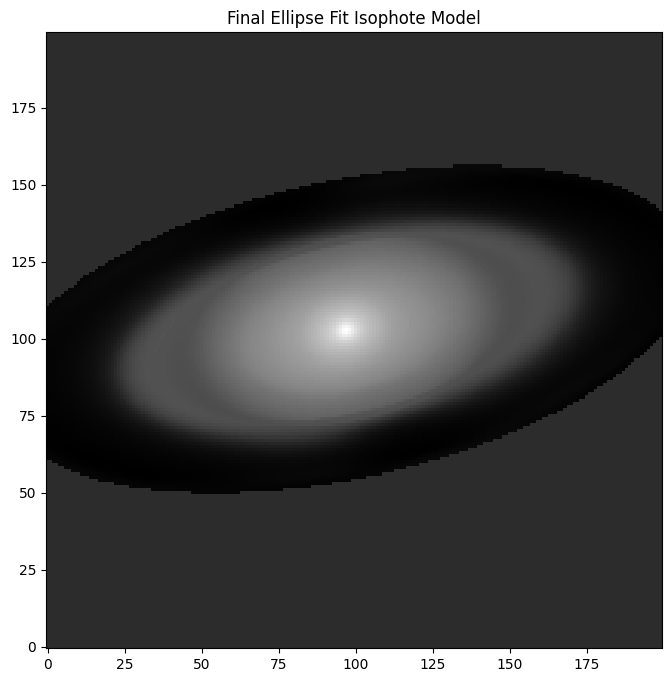

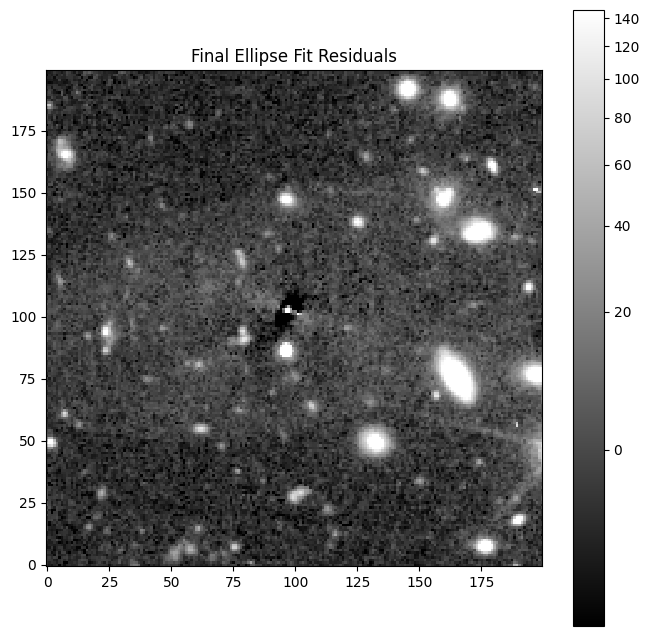

In [12]:
ellipsefitter = 'v4'
print("\n3. Fitting initial ellipse model ...")
residual_basic, model_basic, geometry = MainFitEllipseModel(data, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, final=False, method=ellipsefitter)

print("\n4. Finding initial source mask ...")
source_mask = maskBackgroundSources(residual_basic, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, r=3)

print("\n5. Fitting final ellipse model ...")
residual_final, model_final, geometry = MainFitEllipseModel(data, mask_cr=source_mask, geometry=geometry, make_plots=make_plots, plot_plots=plot_plots, final=True, image_path=image_path,method=ellipsefitter)
print(geometry)


6. Finding final source mask ...


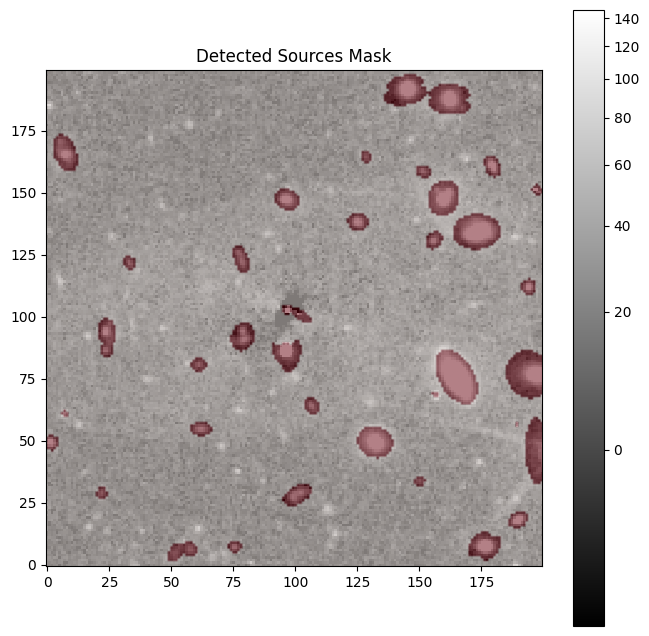


7. Creating required variables ...


/root/MasterThesis/SBF_Pipeline/functions/sourcemasking.py:315: RuntimeWarning: invalid value encountered in sqrt
  nri = (data - model_final) / np.sqrt(model_final)
/root/MasterThesis/SBF_Pipeline/functions/sourcemasking.py:315: RuntimeWarning: divide by zero encountered in divide
  nri = (data - model_final) / np.sqrt(model_final)


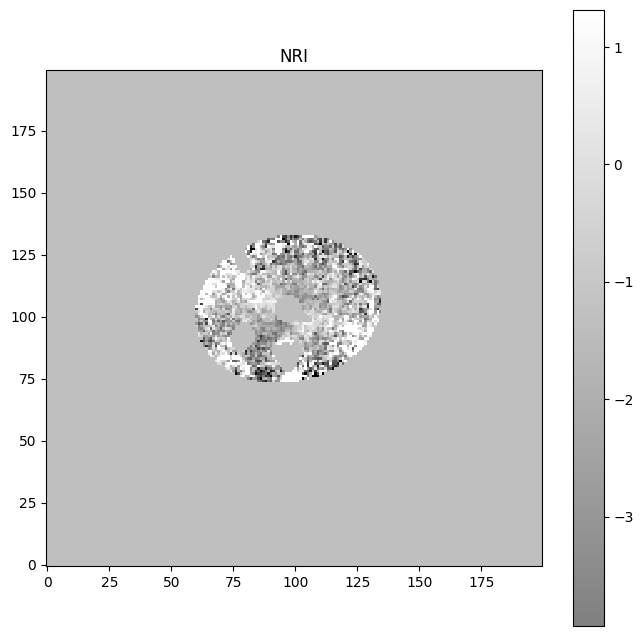


8 Calculate power spectra  ...


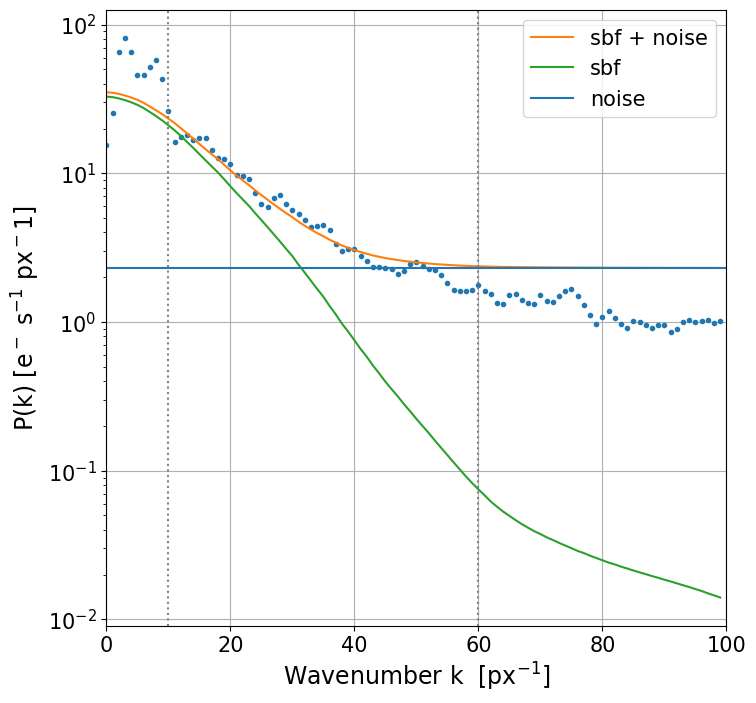


9. Calculate sbf magnitude


In [13]:
print("\n6. Finding final source mask ...")
source_mask_final = maskBackgroundSources(residual_final, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, image_path=image_path, final=True, original_image=data, r=3)

print("\n7. Creating required variables ...")
mask_model, mask_combined, nri = createRequiredVariables(data, model_final, source_mask_final, total_bckgr, geometry, make_plots=make_plots, plot_plots=plot_plots, image_path=image_path)

print("\n8 Calculate power spectra  ...")
image_ps, expected_ps, sbf, noise = calculateSBF(nri, mask_combined, psf,
                                                    norm_type = "MaskedPixels",
                                                    fit_range_i=0.1, fit_range_f=0.6,  
                                                    make_plots=make_plots,plot_plots=plot_plots,
                                                    image_path=image_path)
print("\n9. Calculate sbf magnitude")
sbfmag = appSBFmagnitude(sbf, mzp)

if file_path != None:
    np.savetxt(file_path + "/data_background_subtracted", data)
    np.savetxt(file_path + "/combined_final_mask", mask_combined)
    np.savetxt(file_path + "/final_model", model_final)
    geometry_params = np.array((geometry.x0, geometry.y0, geometry.sma, geometry.eps, geometry.pa))
    np.savetxt(file_path + "/geometry", geometry_params)


In [14]:
print(sbf, sbfmag, total_bckgr, geometry.sma, mzp)

38.04475721759397 26.049262957506002 71.62804586453946 37.852336196709615 30.0
